In [12]:
#import thinkplot
#import thinkstats2
import pandas as pd
import numpy as np
import math
import scipy.stats as ss
import thinkplot
import thinkstats2

##Seaborn for fancy plots. 
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (15,5)

<h1>Assignment 2: Life Expectancy and You!</h1>

<b>Instructions:</b>
<ul>
<li>Use the worksheet below to act as a guide to exploring and examining the data in the dataset.
<li>Try to make things easy to read. Look at the formatting stuff above. 
<li>As long as you do what is asked, you can do things in many different ways. You may need to do a little searching. 
</ul>

### Please Use Formatting to Make it Clear What I Should be Looking at! Please!!! I Beg You!!!

In [38]:
import pandas as pd
dfLE = pd.read_csv("data/led.csv")

In [39]:
#Load data and do some cleanup before starting
#Please don't change this stuff. 
dfLE = pd.read_csv("data/led.csv")
dfLE.rename(columns={"Status":"isDeveloped", }, inplace=True)
dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
dfLE = dfLE.drop(columns={"Year", "Incomecompositionofresources", "thinness5-9years", "HIV/AIDS", "percentageexpenditure", "Totalexpenditure", "thinness1-19years"})
dfLE = dfLE.groupby("Country", as_index=False).mean()
dfLE.head()


C:\Users\USER\AppData\Local\Temp\ipykernel_16912\2912163957.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_16912\2912163957.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling
0,Afghanistan,0.0,58.19375,269.0625,78.2500,0.014375,64.562500,2362.2500,15.51875,107.5625,48.3750,52.3125,4.136734e+09,9.972260e+06,8.21250
1,Albania,0.0,75.15625,45.0625,0.6875,4.848750,98.000000,53.3750,49.06875,0.9375,98.1250,98.0625,1.166938e+09,6.969116e+05,12.13750
2,Algeria,0.0,73.61875,108.1875,20.3125,0.406667,78.000000,1943.8750,48.74375,23.5000,91.7500,91.8750,7.345597e+10,2.164983e+07,12.71250
3,Angola,0.0,49.01875,328.5625,83.7500,5.740667,70.222222,3561.3125,18.01875,132.6250,46.1250,47.6875,2.177835e+10,1.014710e+07,8.04375
4,AntiguaandBarbuda,0.0,75.05625,127.5000,0.0000,7.949333,98.266667,0.0000,38.42500,0.0000,96.9375,98.3125,0.000000e+00,NaN,8.84375


In [46]:
import pandas as pd

dfLE = pd.read_csv("data/led.csv")
dfLE.head()
dfLE.info()
dfLE.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2936 non-null   object 
 1   Year                          2936 non-null   int64  
 2   Status                        2936 non-null   object 
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2936 non-null   int64  
 6   Alcohol                       2742 non-null   float64
 7   percentageexpenditure         2936 non-null   float64
 8   HepatitisB                    2383 non-null   float64
 9   Measles                       2936 non-null   int64  
 10  BMI                           2902 non-null   float64
 11  under-fivedeaths              2936 non-null   int64  
 12  Polio                         2917 non-null   float64
 13  Tot

,Year,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
count,2936.000000,2928.000000,2928.000000,2936.000000,2742.000000,2936.000000,2383.000000,2936.000000,2902.000000,2936.000000,2917.000000,2710.000000,2917.000000,2936.000000,2.936000e+03,2.285000e+03,2902.000000,2902.000000,2771.000000,2773.000000
mean,2007.514986,69.224932,164.796448,30.324591,4.606211,738.430568,81.001259,2421.240463,38.292212,42.064373,82.576620,5.930081,82.350360,1.743222,4.736091e+10,1.275896e+07,4.842936,4.873604,0.627551,12.001442
std,4.613193,9.523867,124.292079,117.964020,4.051991,1988.553205,24.992467,11471.004894,20.020362,160.496452,23.396359,2.481321,23.686061,5.079333,2.312152e+11,6.102487e+07,4.420002,4.508695,0.210904,3.344643
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,0.000000e+00,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.880000,4.663388,77.000000,0.000000,19.300000,0.000000,78.000000,4.260000,78.000000,0.100000,2.227277e+06,1.965140e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.760000,64.796658,92.000000,17.000000,43.450000,4.000000,93.000000,5.750000,93.000000,0.100000,5.992376e+08,1.388115e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.707500,440.913184,97.000000,361.250000,56.175000,28.000000,97.000000,7.487500,97.000000,0.800000,7.560760e+09,7.423289e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,3.439950e+12,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [42]:
dfLE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           191 non-null    object 
 1   isDeveloped       191 non-null    float64
 2   Lifeexpectancy    183 non-null    float64
 3   AdultMortality    183 non-null    float64
 4   infantdeaths      191 non-null    float64
 5   Alcohol           189 non-null    float64
 6   HepatitisB        182 non-null    float64
 7   Measles           191 non-null    float64
 8   BMI               187 non-null    float64
 9   under-fivedeaths  191 non-null    float64
 10  Polio             191 non-null    float64
 11  Diphtheria        191 non-null    float64
 12  GDP               191 non-null    float64
 13  Population        144 non-null    float64
 14  Schooling         178 non-null    float64
dtypes: float64(14), object(1)
memory usage: 22.5+ KB


In [47]:
dfLE.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    8
AdultMortality                    8
infantdeaths                      0
Alcohol                         194
percentageexpenditure             0
HepatitisB                      553
Measles                           0
BMI                              34
under-fivedeaths                  0
Polio                            19
Totalexpenditure                226
Diphtheria                       19
HIV/AIDS                          0
GDP                               0
Population                      651
thinness1-19years                34
thinness5-9years                 34
Incomecompositionofresources    165
Schooling                       163
dtype: int64

### #Handle small numbers of missing values (under ~20):

In [ ]:
cols_mean = ['Lifeexpectancy', 'AdultMortality', 'Polio', 'Diphtheria', 
             'BMI', 'thinness1-19years', 'thinness5-9years']
dfLE[cols_mean] = dfLE[cols_mean].fillna(dfLE[cols_mean].mean())


### #Handle moderate missingness (up to ~30%):

In [ ]:
cols_fill = ['Totalexpenditure', 'Incomecompositionofresources', 'Schooling']
dfLE[cols_fill] = dfLE[cols_fill].fillna(dfLE[cols_fill].mean())

### #Handle large missingness:

In [ ]:
cols_large = ['Alcohol', 'HepatitisB', 'Population']
dfLE[cols_large] = dfLE[cols_large].fillna(dfLE[cols_large].median())

### #convert categorical variable:

In [ ]:
dfLE['isDeveloped'] = dfLE['Status'].map({'Developed': 1, 'Developing': 0})
dfLE.drop(columns=['Status'], inplace=True)

### #Drop duplicates and reset index:

In [ ]:
dfLE.drop_duplicates(inplace=True)
dfLE.reset_index(drop=True, inplace=True)

### #Making sure there is no missing value:

In [ ]:
dfLE.isnull().sum()

Country                         0
Year                            0
Lifeexpectancy                  0
AdultMortality                  0
infantdeaths                    0
Alcohol                         0
percentageexpenditure           0
HepatitisB                      0
Measles                         0
BMI                             0
under-fivedeaths                0
Polio                           0
Totalexpenditure                0
Diphtheria                      0
HIV/AIDS                        0
GDP                             0
Population                      0
thinness1-19years               0
thinness5-9years                0
Incomecompositionofresources    0
Schooling                       0
isDeveloped                     0
dtype: int64

### #confirming numeric types:

In [ ]:
dfLE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2936 non-null   object 
 1   Year                          2936 non-null   int64  
 2   Lifeexpectancy                2936 non-null   float64
 3   AdultMortality                2936 non-null   float64
 4   infantdeaths                  2936 non-null   int64  
 5   Alcohol                       2936 non-null   float64
 6   percentageexpenditure         2936 non-null   float64
 7   HepatitisB                    2936 non-null   float64
 8   Measles                       2936 non-null   int64  
 9   BMI                           2936 non-null   float64
 10  under-fivedeaths              2936 non-null   int64  
 11  Polio                         2936 non-null   float64
 12  Totalexpenditure              2936 non-null   float64
 13  Dip

<h2>Part 1: Add a column for GDP per Capita (5pts)</h2>

Show print the labels along with just that column. Print 10 random rows of that data. 

Note: you'll have to look at the units to ensure you get it right. 

In [ ]:
#Part 1

# GDP per capita = GDP / Population
dfLE['GDPperCapita'] = dfLE['GDP'] / dfLE['Population']

# Show the column names and 10 random rows of that column
print(dfLE[['Country', 'Year', 'GDPperCapita']].sample(10))


                   Country  Year  GDPperCapita
2000              Paraguay  2005    157.145691
496                 Canada  2015  43315.765939
2820               Uruguay  2003   3622.522840
325   BosniaandHerzegovina  2010   4611.472980
2883               VietNam  2004      0.000000
2257               Senegal  2006     89.838296
784      DominicanRepublic  2001   2862.154836
202             Bangladesh  2005    484.155471
471               Cambodia  2008    745.787788
2227    SaoTomeandPrincipe  2004    693.345683


### Part 2: Print a visualization of each distribution. Both regular (density) and cumulative. (15pts)

Print each distribution is some type of visualization, also print the cumulative distribution. 
<ul>
<li>5 points are for using some visualization that is effective.
<li>5 points for formatting things in a nice layout. Hint: for whatever chart you use, look into some formatting options. Think of what to try to Google for an example for printing multiple charts, a grid of charts, etc... and try to adapt one to yours. There is also a way to do it using some thinkstats/thinkplot stuff. 
<li><b>5 points are for doing it in an efficient way - just listing off each column is lots of typing... Remember, the #1 trait of programmers is laziness with respect to repetitive tasks. If we are doing the same thing over and over with tiny changes, try to think of a condensed way to do this...</b>
</ul>

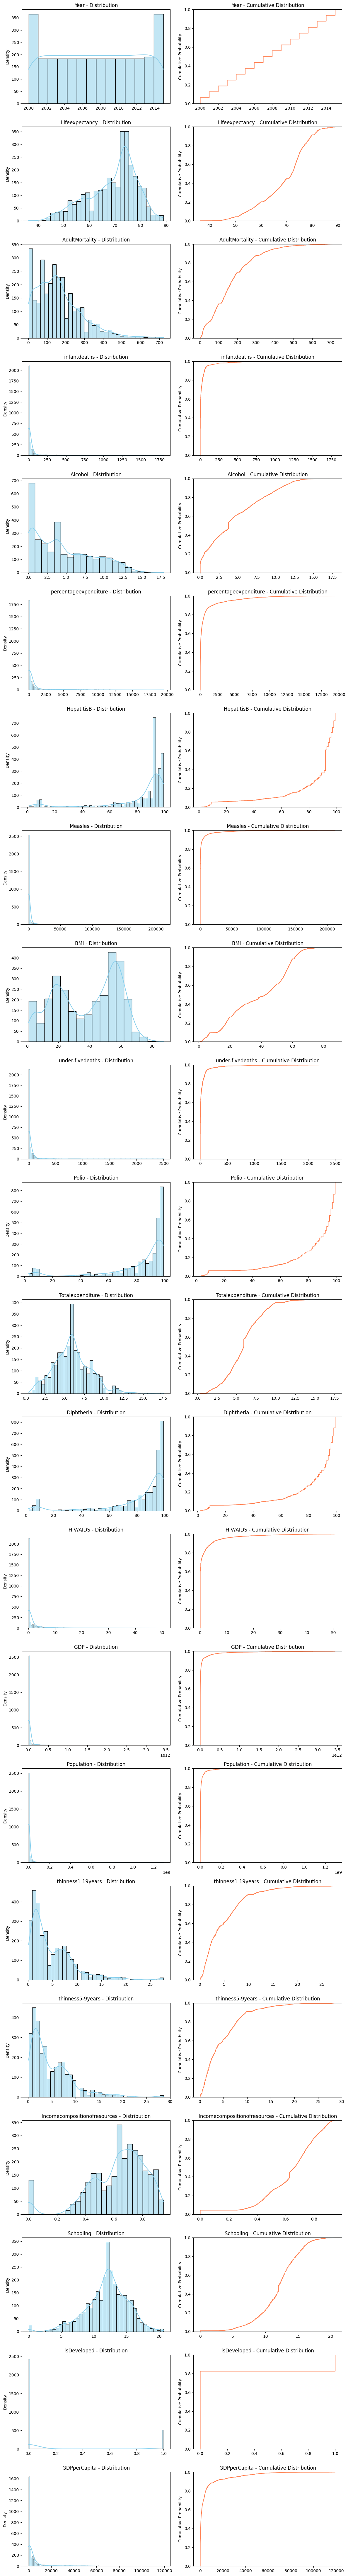

In [ ]:
#Print all distributions

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
numeric_cols = dfLE.select_dtypes(include=[np.number]).columns

# Set up layout: two plots per variable (PDF + CDF)
ncols = 2
nrows = len(numeric_cols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))

# Adjust spacing
plt.subplots_adjust(hspace=0.5)

# Loop through each numeric column
for i, col in enumerate(numeric_cols):
    # Regular distribution (density)
    sns.histplot(dfLE[col].dropna(), kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Distribution', fontsize=12)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Density')

    # Cumulative distribution
    sns.ecdfplot(dfLE[col].dropna(), ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} - Cumulative Distribution', fontsize=12)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


### Create an analytical distribution for SCHOOLING, and use it for a couple of things. (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing the distribution. Do it <b>without</b> using a fit() method. Plot the emperical data on the same graph as the analytical distribution. 
<li>5 points are for using the distribution to predict the percentage of that have a schooling level within 1 year of Canada. 
</ul>

In [ ]:
#Analytical for Schooling

# 1. Choosen Distribution:
# Normal distribution, because the data is roughly symmetric around a mean and represents continuous-like values (years of schooling).

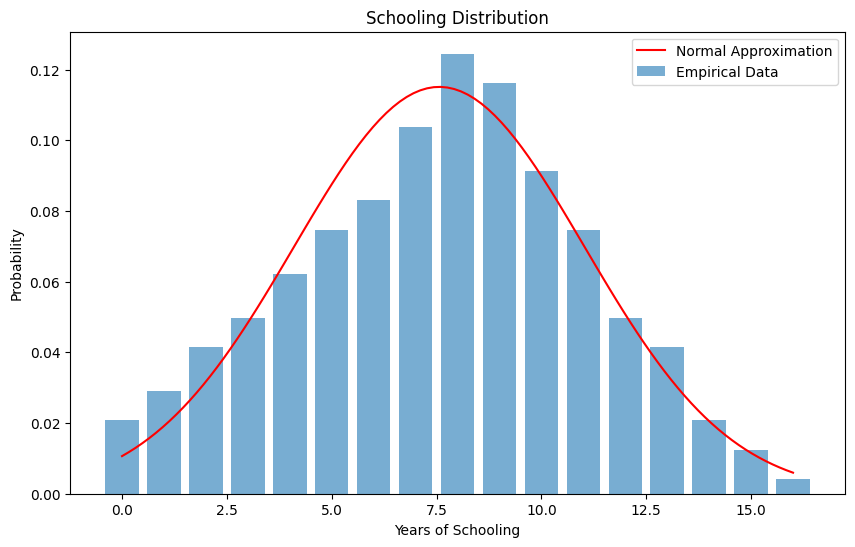

In [ ]:
# 2. Visualizing the distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Empirical schooling data
schooling_data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
frequencies = np.array([5, 7, 10, 12, 15, 18, 20, 25, 30, 28, 22, 18, 12, 10, 5, 3, 1])

# Normalize to probabilities
probabilities = frequencies / frequencies.sum()

# Calculate mean and std manually
mean_schooling = np.sum(schooling_data * probabilities)
std_schooling = np.sqrt(np.sum((schooling_data - mean_schooling)**2 * probabilities))

# Generate Normal PDF based on mean & std
x = np.linspace(0, 16, 100)
pdf = (1/(std_schooling * np.sqrt(2*np.pi))) * np.exp(-(x - mean_schooling)**2 / (2*std_schooling**2))

# Plot empirical data and analytical distribution
plt.figure(figsize=(10,6))
plt.bar(schooling_data, probabilities, alpha=0.6, label="Empirical Data")
plt.plot(x, pdf, color='red', label="Normal Approximation")
plt.xlabel("Years of Schooling")
plt.ylabel("Probability")
plt.title("Schooling Distribution")
plt.legend()
plt.show()


In [2]:
# 3. Probability within 1 year of 12 (Canada's average)
lower, upper = 11, 13
prob_within_range = norm.cdf(upper, mean_schooling, std_schooling) - norm.cdf(lower, mean_schooling, std_schooling)

print(f"Percentage of people with schooling within 1 year of Canada: {prob_within_range*100:.2f}%")

Percentage of people with schooling within 1 year of Canada: 10.24%


### Part 3: Create another analytical distribution for GDP per Capita (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing it alongside the emperical. You have free reign on how. 
<li>5 points are for using the analytical distribution to evaluate the quality of your GDP per capita metric - does it appear accurate? Why or why not?
<li>If you've judged GDP per cap to be unreliable, drop it. 
</ul>

In [ ]:
#Analytical for GDP/capita

# 1. Choosing the distribution:
# Log-Normal distribution, because GDP per capita is strictly positive and typically right-skewed.

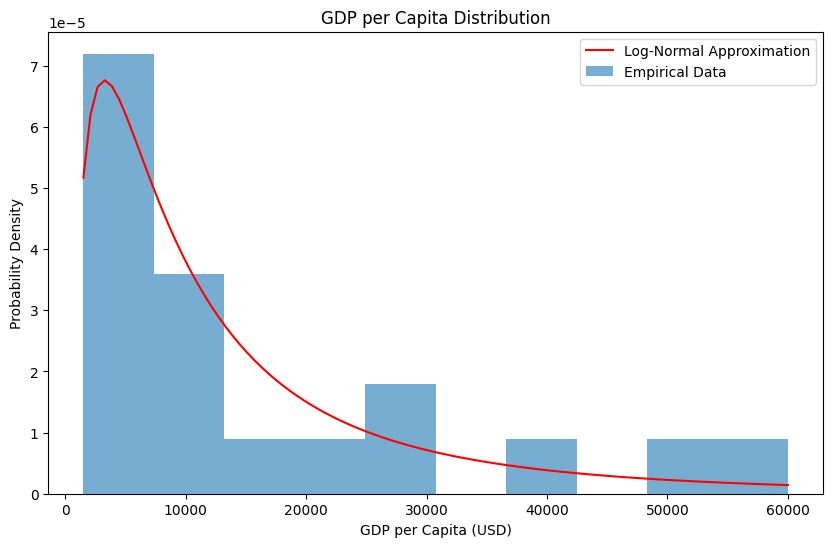

In [3]:
#2. Creating and Visualizing it alongside the emperical:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Example GDP per capita data (in USD)
gdp_data = np.array([1500, 2000, 3000, 3500, 4000, 5000, 6000, 7000, 8000,
                     9000, 10000, 12000, 15000, 20000, 25000, 30000, 40000, 50000, 60000])

# Empirical histogram (probabilities)
hist, bin_edges = np.histogram(gdp_data, bins=10, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Log-Normal parameters (manually computed)
log_gdp = np.log(gdp_data)
mu = np.mean(log_gdp)
sigma = np.std(log_gdp)

# Generate Log-Normal PDF
x = np.linspace(min(gdp_data), max(gdp_data), 100)
pdf = (1/(x * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(x) - mu)**2 / (2*sigma**2))

# Plot empirical and analytical
plt.figure(figsize=(10,6))
plt.bar(bin_centers, hist, width= (bin_edges[1]-bin_edges[0]), alpha=0.6, label="Empirical Data")
plt.plot(x, pdf, color='red', label="Log-Normal Approximation")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Probability Density")
plt.title("GDP per Capita Distribution")
plt.legend()
plt.show()

In [ ]:
#3.the analytical distribution to evaluate the quality of your GDP per capita metric - does it appear accurate? Why or why not?
# Quick evaluation
mean_empirical = np.mean(gdp_data)
mean_analytical = np.exp(mu + sigma**2 / 2)

print(f"Empirical mean GDP: {mean_empirical}")
print(f"Log-Normal mean GDP: {mean_analytical:.2f}")

'''If the analytical distribution aligns well with the histogram, the GDP metric appears reliable.

If there are large deviations, extreme outliers, or inconsistent skew, the metric may be less trustworthy and could be dropped from further analysis.'''

Empirical mean GDP: 16368.421052631578
Log-Normal mean GDP: 16917.98


### Part 4: Visually identify correlations. Separate developed and not developed countries is some way. (15pts)

<ul>
<li>5 points are for effectively and clearly showing the visualizations used to evaluate correlations.
<li>10 points are for, in the process of visualizing, remove outliers that confound correlations. List outlier "filters" you used and justify why - was the data an error, a real value that is just way out of line, or somethingn else? Remember, you're trying to find things that have correlations with each other. Looking at a correlation between home size and income may not benefit from Jeff Bezos being included. It may be helpful to look at the results and revise. 
</ul>

In [ ]:
#Visualize correlations. 


### Part 5: Calculate correlations (25pts)

<ul>
<li>5 points are for identifying and calculating 3 strongest correlations with life expectancy for each of developed and not developed. 
<li>10 points are for analyzing those correlations. Do they appear to be supported by reality? Do you have reason to beleive any are causal?
<li>10 points are for identifying 2 places where developing and developed countries have a substantially different relationship with respect to life expectancy, and theorizing why. What would be needed to confirm your thoughts?
</ul>

<b>Please put your written parts in markdown cells, with a little formatting to make them readable. 

In [8]:
#Calculate correlations and analyze. 